<a href="https://colab.research.google.com/github/BrendonKappel/previsao-aprovacao-emprestimo-rna/blob/master/Trabalho_RNA(IA_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sobre o Conjunto de Dados (Dataset)

## 1. Fonte dos Dados

Este conjunto de dados é uma versão sintética inspirada no dataset original de Risco de Crédito (*Credit Risk*) no Kaggle e enriquecida com variáveis adicionais baseadas em dados de Risco Financeiro para Aprovação de Empréstimos. A técnica SMOTENC foi utilizada para simular novos pontos de dados a fim de ampliar o número de instâncias. O conjunto de dados está estruturado tanto com características categóricas quanto contínuas.

## 2. Metadados

O conjunto de dados contém 45.000 registros e 14 variáveis, cada uma descrita abaixo:

| Coluna | Descrição | Tipo |
| :--- | :--- | :--- |
| `person_age` | Idade da pessoa | Float (Contínuo) |
| `person_gender` | Gênero da pessoa | Categórico |
| `person_education` | Maior nível de escolaridade | Categórico |
| `person_income` | Renda anual | Float (Contínuo) |
| `person_emp_exp` | Anos de experiência profissional | Inteiro |
| `person_home_ownership` | Status de propriedade da casa (ex: alugada, própria, hipotecada) | Categórico |
| `loan_amnt` | Valor do empréstimo solicitado | Float (Contínuo) |
| `loan_intent` | Finalidade do empréstimo | Categórico |
| `loan_int_rate` | Taxa de juros do empréstimo | Float (Contínuo) |
| `loan_percent_income` | Valor do empréstimo como percentual da renda anual | Float (Contínuo) |
| `cb_person_cred_hist_length` | Tempo de histórico de crédito em anos | Float (Contínuo) |
| `credit_score` | Pontuação de crédito (Score) da pessoa | Inteiro |
| `previous_loan_defaults_on_file` | Indicador de inadimplências anteriores em empréstimos | Categórico |
| `loan_status` (variável alvo) | Status de aprovação do empréstimo: 1 = aprovado; 0 = rejeitado | Inteiro |


# Sobre o tratamento dos Dados e Criação do Modelo

## Bibliotecas Utilizadas

- **Pandas** – carregamento, manipulação e tratamento dos dados.

- **NumPy** – operações matemáticas e manipulação eficiente de vetores e matrizes.

- **Scikit-Learn** – divisão treino/teste, normalização, métricas de avaliação e implementação da RNA (MLPClassifier).

- **Matplotlib** – geração de gráficos, como a curva de erro do treinamento.

- **Seaborn** – histogramas e boxplots (distribuições e outliers).

##1. Importação da base de dados



In [2]:
import pandas as pd
import kagglehub

# Baixar a versão mais recente do arquivo diretamente do Kaggle
dataset_kaggle_path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
print("Path to dataset files:", dataset_kaggle_path)

# Ler arquivo csv como um dataframe
dataset_local_path = "/kaggle/input/loan-approval-classification-data/loan_data.csv"
df = pd.read_csv(dataset_local_path)

df.head()

Using Colab cache for faster access to the 'loan-approval-classification-data' dataset.
Path to dataset files: /kaggle/input/loan-approval-classification-data


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 2. Data Profiling e Interpretação do Dataset

Análise exploratória inicial dos dados, abrangendo:

- Quantidade de linhas e colunas
- Tipos de dados de cada coluna
- Estatísticas descritivas das variáveis numéricas
- Verificação de valores ausentes
- Verificação de valores duplicados
- Distribuição das variáveis numéricas (histogramas e boxplots)
- Frequência das variáveis categóricas
- Detecção visual de outliers

Informações do Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19942 entries, 0 to 19941
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      19942 non-null  int64  
 1   person_gender                   19942 non-null  object 
 2   person_education                19942 non-null  object 
 3   person_income                   19942 non-null  float64
 4   person_emp_exp                  19942 non-null  int64  
 5   person_home_ownership           19942 non-null  object 
 6   loan_amnt                       19942 non-null  float64
 7   loan_intent                     19942 non-null  object 
 8   loan_int_rate                   19942 non-null  float64
 9   loan_percent_income             19942 non-null  float64
 10  cb_person_cred_hist_length      19942 non-null  float64
 11  credit_score                    19942 non-null  int64  
 12  previous_

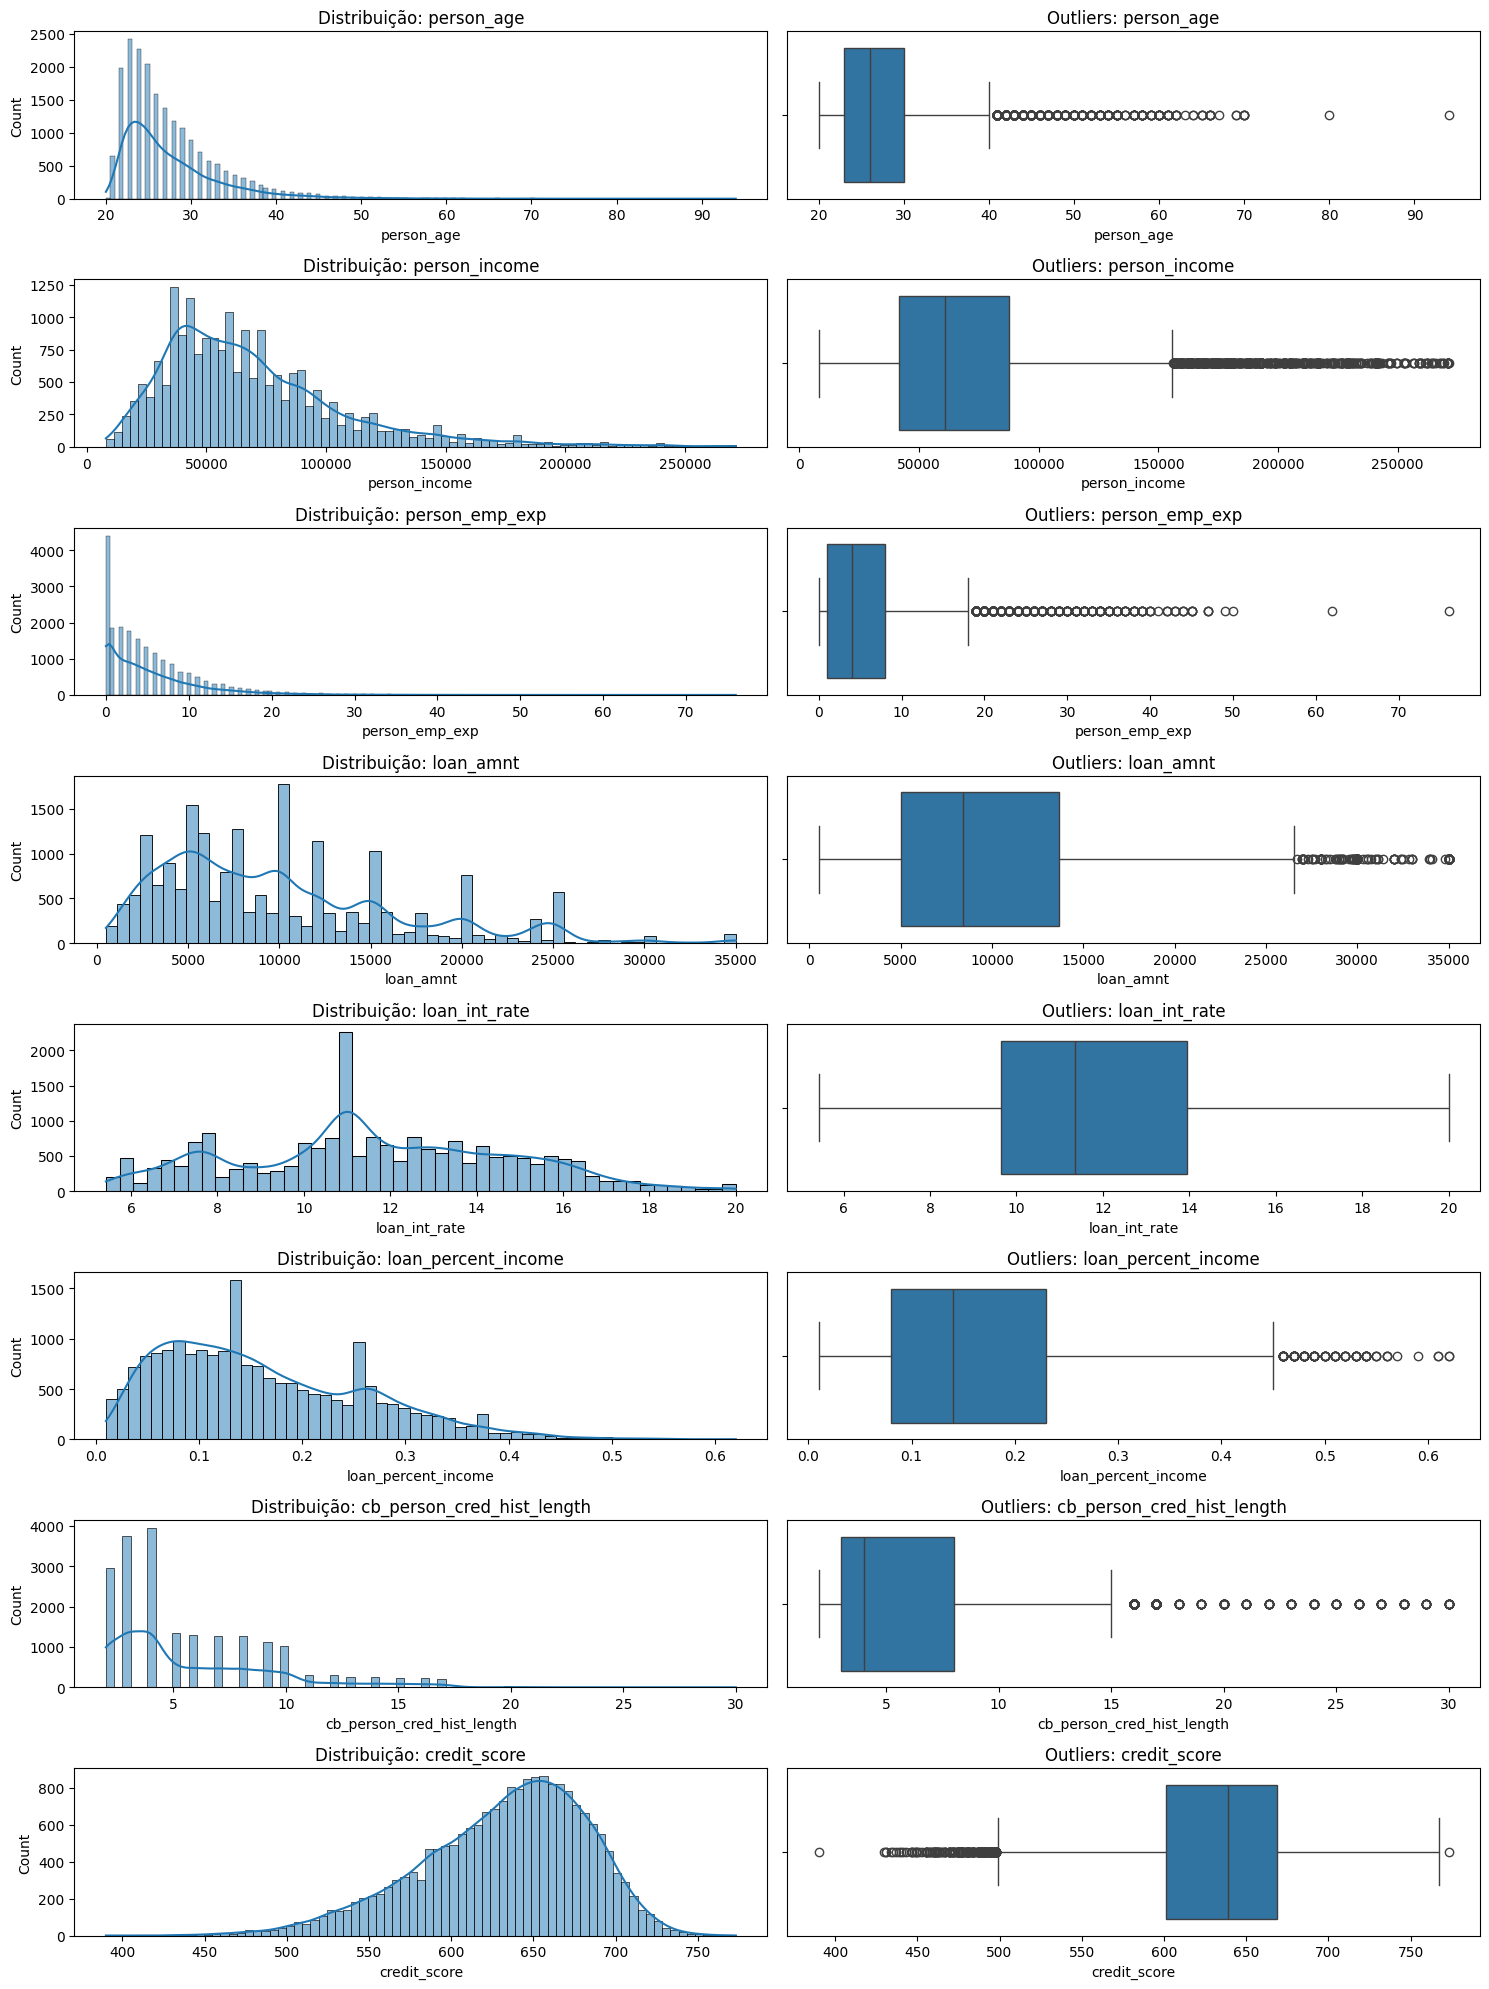

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Quantidade de linhas/colunas e Tipos de dados
print("Informações do Dataset")
df.info()

# 2. Verificação de valores ausentes
print("\n\nValores Ausentes")
print(df.isnull().sum())

# 3. Verificação de valores duplicados
print(f"\n\nQuantidade de registros duplicados: {df.duplicated().sum()}")

# 4. Estatísticas descritivas (Numéricas)
print("\n\nEstatísticas Descritivas")
print(df.describe())

# 5. Frequência das variáveis categóricas
print("\n\nFrequência das Variáveis Categóricas")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nDistribuição de {col}:")
    print(df[col].value_counts())

# 6. Distribuições e Outliers (Visual)
print("\n\nAnálise Visual (Histogramas e Boxplots)")
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('loan_status', errors='ignore')

plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, 2*i-1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição: {col}')

    plt.subplot(len(num_cols), 2, 2*i)
    sns.boxplot(x=df[col])
    plt.title(f'Outliers: {col}')

plt.tight_layout()
plt.show()

## 3. Data Cleaning

Tratamento dos problemas identificados na etapa anterior:

- **Valores ausentes:** não foram encontrados valores ausentes no dataset.
- **Duplicatas:** não foram encontradas linhas duplicadas.
- **Correção de tipos de dados:**
  - `person_age`: convertida de `float64` para `int64`.
- **Tratamento de outliers:**
  - `person_age` (idade): valor máximo registrado de 144 anos.
  - `person_emp_exp` (anos de experiência): valor máximo registrado de 125 anos.
  - `person_income` (renda anual): distribuição com assimetria extrema à direita — média de 80 mil, mas valor máximo de 7,2 milhões. Embora rendas elevadas sejam plausíveis, valores tão extremos podem distorcer o aprendizado do modelo.

In [ ]:
initial_total = df.shape[0]

# 1. Tratar outliers
# Remover registros com idade improvável (acima de 100 anos)
df = df[df['person_age'] <= 100]

# Experiência é realista em relação à idade (idade - 14 anos)
df = df[df['person_emp_exp'] <= (df['person_age'] - 14)]

# Remover rendas que distorcem muito da realidade da maioria (acima do percentil 99)
income_limit = df['person_income'].quantile(0.99)
df = df[df['person_income'] <= income_limit]

# 2. Corrigir tipos de dados
df['person_age'] = df['person_age'].astype('int64')

# 3. Resumo da limpeza
final_total = df.shape[0]

print("Resumo do Data Cleaning\n")
print(f"Total de registros iniciais: {initial_total}")
print(f"Total de registros após a limpeza direta: {final_total}")
print(f"Total de registros problemáticos removidos: {initial_total - final_total}\n")

Resumo do Data Cleaning

Total de registros iniciais: 45000
Total de registros após a limpeza direta: 44543
Total de registros problemáticos removidos: 457



## 4. Feature Engineering

Não foi necessária a criação de novas variáveis, visto que o conjunto de dados já apresenta atributos suficientes e relevantes para a tarefa de classificação proposta.

## 5. Balanceamento de Dados

Os dados originais estão desbalanceados, com aproximadamente 35 mil registros de empréstimos não aprovados e 10 mil aprovados.

**Estratégia adotada:** redução do número de registros da classe majoritária (não aprovados), mantendo aproximadamente 10 mil registros para cada classe.

In [ ]:
not_approved = df[df['loan_status'] == 0]
approved = df[df['loan_status'] == 1]

not_approved = not_approved.sample(
    n=10000,
    random_state=42
)

df = pd.concat([
    not_approved,
    approved
])

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df['loan_status'].value_counts())

loan_status
0    10000
1     9942
Name: count, dtype: int64


##6. Separação de X e Y



In [ ]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (19942, 13)
Dimensões de y: (19942,)


## 7. Separação dos Conjuntos de Treino e Teste

Os dados foram divididos em 70% para treino e 30% para teste.

Essa separação é feita antes da normalização para evitar *data leakage*: assim, a média e os valores mínimos/máximos do conjunto de teste não influenciam o ajuste do scaler, garantindo uma avaliação mais realista do modelo.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (13959, 13)
X_test:  (5983, 13)
y_train: (13959,)
y_test:  (5983,)


## 8. Encoding

Conversão das variáveis categóricas (texto) em valores numéricos, utilizando codificação binária e one-hot encoding, de forma que possam ser processadas pela rede neural.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

X_train = X_train.copy()
X_test = X_test.copy()

# 1. Mapeamento Binário manual
mapping_default = {'No': 0, 'Yes': 1}
X_train['previous_loan_defaults_on_file'] = X_train['previous_loan_defaults_on_file'].map(mapping_default)
X_test['previous_loan_defaults_on_file'] = X_test['previous_loan_defaults_on_file'].map(mapping_default)

# 2. Usando o One-Hot Scikit-Learn
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# O encoder aprende as categorias do treino e transforma
encoded_train = encoder.fit_transform(X_train[cat_cols])
# O encoder apenas transforma o teste usando o que aprendeu no treino
encoded_test = encoder.transform(X_test[cat_cols])

# Convertendo de volta para DataFrame com os nomes corretos das colunas
encoded_cols = encoder.get_feature_names_out(cat_cols)
X_train_encoded = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)

# Juntando as novas colunas numéricas com o resto do dataset e dropando as antigas de texto
X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_encoded], axis=1)

X_train.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_gender_female,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
19699,27,92239.0,4,24000.0,10.99,0.26,5.0,662,0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
17500,45,72642.0,18,25782.0,9.71,0.35,17.0,617,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
19529,37,51403.0,12,12000.0,11.01,0.23,13.0,622,1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1829,31,90691.0,8,6500.0,10.46,0.07,10.0,553,1,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
15430,25,50008.0,1,8496.0,11.03,0.17,4.0,568,0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Verificar se existem somente colunas númericas
print(X_train.dtypes.value_counts())

float64    22
int64       4
Name: count, dtype: int64


## 9. Normalização

As variáveis numéricas contínuas foram colocadas na mesma escala, utilizando o `StandardScaler`.

**Observações:**
- A variável alvo (*target*) não é normalizada.
- As variáveis resultantes do *one-hot encoding* não precisam de normalização.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Apenas variáveis númericas contínuas
num_cols = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Após a aplicação do `StandardScaler`, os valores de média e desvio padrão de cada variável devem ficar aproximadamente iguais aos valores abaixo:

- **Média ≈ 0**
- **Desvio padrão ≈ 1**

In [ ]:
print(X_train[num_cols].describe().T[['mean', 'std']])

                                    mean       std
person_age                  2.265144e-16  1.000036
person_income               1.432895e-16  1.000036
person_emp_exp             -2.443302e-17  1.000036
loan_amnt                  -2.417851e-17  1.000036
loan_int_rate              -9.365991e-17  1.000036
loan_percent_income        -9.365991e-17  1.000036
cb_person_cred_hist_length -6.922689e-17  1.000036
credit_score               -3.278097e-16  1.000036


## 10. Testes com Diferentes Parâmetros e Arquiteturas

O modelo escolhido foi o **MLPClassifier** (Multi-Layer Perceptron), uma Rede Neural Artificial composta por camadas de neurônios conectadas entre si. Cada neurônio processa as informações recebidas, aplica uma função de ativação e passa o resultado para a próxima camada, até chegar a uma saída final (aprovado ou não aprovado). O treinamento ocorre ajustando os pesos dessas conexões de forma iterativa, buscando reduzir o erro de previsão a cada iteração.

### Teste 1: Definição do Número de Neurônios e Taxa de Aprendizado

Objetivo: encontrar a combinação de número de neurônios e taxa de aprendizado que apresente o melhor desempenho para o problema.

- **Número de neurônios testados:** 8, 16, 32
- **Taxas de aprendizado testadas:** 0.01, 0.001

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

results = []

configs = [
    {"hidden_layer_sizes": (8,),  "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (8,),  "learning_rate_init": 0.001},

    {"hidden_layer_sizes": (16,), "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (16,), "learning_rate_init": 0.001},

    {"hidden_layer_sizes": (32,), "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (32,), "learning_rate_init": 0.001},
]

for cfg in configs:

    mlp = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation='relu',
        solver='adam',
        learning_rate_init=cfg["learning_rate_init"],
        max_iter=300,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    y_pred = mlp.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Neurons": cfg["hidden_layer_sizes"][0],
        "Learning Rate": cfg["learning_rate_init"],
        "Accuracy": acc,
        "Iterations": mlp.n_iter_,
        "Loss": mlp.loss_
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Neurons,Learning Rate,Accuracy,Iterations,Loss
0,8,0.010,0.893365,80,0.217835
1,8,0.001,0.890690,146,0.222824
2,16,0.010,0.890523,100,0.200370
3,16,0.001,0.888016,200,0.209861
5,32,0.001,0.883838,257,0.194955
4,32,0.010,0.882333,146,0.188331


### Teste 2: Adição de Camadas Ocultas

Objetivo: a partir do melhor resultado da etapa anterior, avaliar o impacto de adicionar camadas ocultas adicionais à arquitetura.

- **Melhor configuração da etapa anterior:** 8 neurônios, taxa de aprendizado de 0.01
- **Arquiteturas testadas:** (8,), (8, 4), (8, 8), (8, 8, 4)

In [ ]:
layer_results = []

architectures = [
    (8,),       # 1 camada oculta
    (8, 4),     # 2 camadas ocultas
    (8, 8),     # 2 camadas ocultas
    (8, 8, 4)   # 3 camadas ocultas
]

for arch in architectures:

    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,  # melhor taxa encontrada
        max_iter=300,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    y_pred = mlp.predict(X_test)

    layer_results.append({
        "Architecture": str(arch),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Iterations": mlp.n_iter_,
        "Loss": mlp.loss_
    })

layer_results_df = pd.DataFrame(layer_results)

layer_results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Architecture,Accuracy,Iterations,Loss
2,"(8, 8)",0.893699,84,0.209060
0,"(8,)",0.893365,80,0.217835
3,"(8, 8, 4)",0.891860,79,0.210564
1,"(8, 4)",0.888350,83,0.209100


### Modelo Final Escolhido

Apesar da arquitetura (8, 8) ter apresentado a maior acurácia, a diferença observada em relação à arquitetura (8,) foi inferior a 0,04%. Por esse motivo, optou-se pela arquitetura **(8,)** — composta por uma única camada oculta com 8 neurônios — devido à sua maior simplicidade computacional e menor complexidade estrutural, mantendo um desempenho praticamente equivalente.

## 11. Treinamento do Modelo Final

Reconstrução da rede neural com as configurações vencedoras das etapas anteriores:

- **Número de neurônios:** 8
- **Camadas ocultas:** 1
- **Taxa de aprendizado:** 0.01


PARÂMETROS DO MODELO RNA VENCEDOR:
Taxa de aprendizado: 0.01
Número de camadas intermediárias: 1
Neurônios nas camadas intermediárias: 8

RESULTADOS DO TREINAMENTO:
Iterações: 80
Erro final: 0.21783466915651198


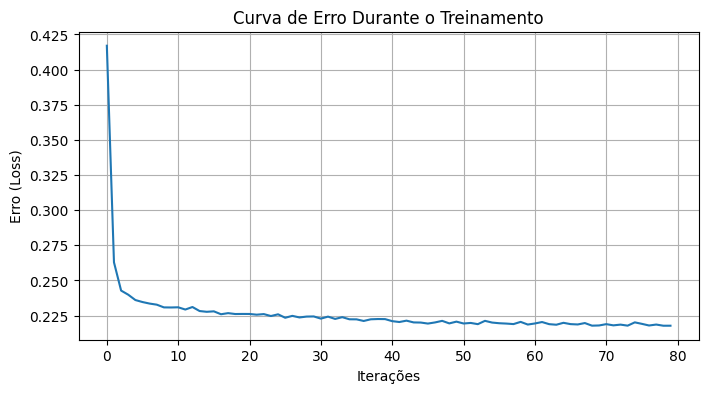

In [ ]:
final_model = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42
)

final_model.fit(X_train, y_train)

print("PARÂMETROS DO MODELO RNA VENCEDOR:")
print(f"Taxa de aprendizado: {final_model.learning_rate_init}")
print(f"Número de camadas intermediárias: {len(final_model.hidden_layer_sizes)}")
print(f"Neurônios nas camadas intermediárias: {final_model.hidden_layer_sizes[0]}\n")

print("RESULTADOS DO TREINAMENTO:")
print("Iterações:", final_model.n_iter_)
print("Erro final:", final_model.loss_)

# Gráfico da curva de erro
plt.figure(figsize=(8, 4))
plt.plot(final_model.loss_curve_)
plt.title("Curva de Erro Durante o Treinamento")
plt.xlabel("Iterações")
plt.ylabel("Erro (Loss)")
plt.grid(True)

plt.show()

In [ ]:
print("PARÂMETROS DO DE RNA MODELO TREINADO:")
print(f"Taxa de aprendizado: {final_model.learning_rate_init}")
print(f"Número de camadas intermediárias: {len(final_model.hidden_layer_sizes)}")
print(f"Neurônios nas camadas intermediárias: {final_model.hidden_layer_sizes[0]}")

PARÂMETROS DO DE RNA MODELO TREINADO:
Taxa de aprendizado: 0.01
Número de camadas intermediárias: 1
Neurônios nas camadas intermediárias: 8


O treinamento começou com um erro alto, próximo de 0,42, mas caiu rapidamente nas primeiras iterações. Por volta da iteração 10-20, o erro já havia se estabilizado em torno de 0,22, e a partir daí permaneceu praticamente constante até a iteração 80. Isso indica que o modelo aprendeu de forma eficiente nas etapas iniciais e atingiu um ponto de equilíbrio

## 12. Métricas

Avaliação do desempenho do modelo final no conjunto de teste, utilizando as seguintes métricas:

- **Acurácia:** percentual total de previsões corretas em relação ao total de registros.
- **Precisão:** dentre os casos previstos como "aprovado", quantos realmente eram aprovados.
- **Recall:** dentre os casos que realmente eram "aprovado", quantos o modelo conseguiu identificar corretamente.
- **F1-score:** média harmônica entre precisão e recall, equilibrando os dois indicadores.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


y_pred = final_model.predict(X_test)

print("ACURÁCIA:")
print(accuracy_score(y_test, y_pred))

print("\nPRECISION:")
print(precision_score(y_test, y_pred))

print("\nRECALL:")
print(recall_score(y_test, y_pred))

print("\nF1:")
print(f1_score(y_test, y_pred))

ACURÁCIA:
0.8933645328430553

PRECISION:
0.8643699565487275

RECALL:
0.9326858673811118

F1:
0.897229381443299


## 13. Matriz de Confusão

Visualização gráfica das previsões corretas e incorretas do modelo.

Matriz de Confusão:
[[2560  437]
 [ 201 2785]]


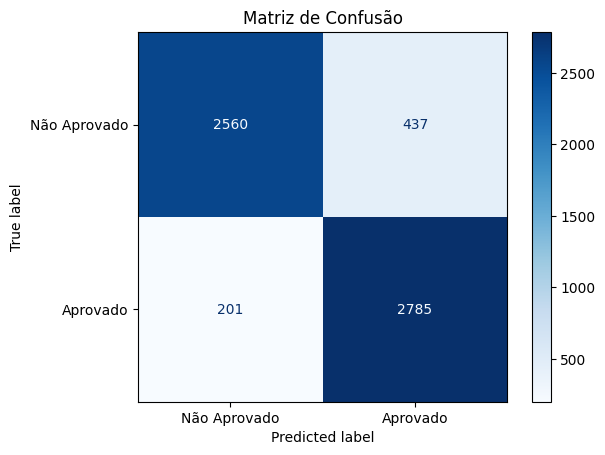

In [ ]:
# Previsões
y_pred = final_model.predict(X_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão:")
print(cm)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Aprovado", "Aprovado"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

A matriz de confusão demonstrou que a rede neural classificou corretamente 2.560 registros da classe "Não Aprovado" e 2.785 registros da classe "Aprovado". Foram observados 437 falsos positivos, correspondentes a registros classificados como aprovados quando pertenciam à classe não aprovada, e 201 falsos negativos, correspondentes a registros classificados como não aprovados quando pertenciam à classe aprovada.

O modelo apresentou um total de 5.345 classificações corretas em 5.983 registros avaliados, resultando em uma acurácia de aproximadamente 89,3%. Os resultados indicam que a rede neural foi capaz de identificar adequadamente ambas as classes, apresentando desempenho equilibrado após o processo de balanceamento dos dados.

## 14. Exemplo Realizando uma Previsão na Prática

Para validar o funcionamento do modelo, foi selecionado um registro do conjunto de teste. O modelo recebeu o padrão de entrada (valores normalizados) e gerou a previsão de classe (aprovado/não aprovado), juntamente com as probabilidades associadas a cada classe.


In [ ]:
index = 0

# Seleciona um registro do conjunto de teste (Use X_test_scaled se o seu modelo foi treinado com escala)
sample = X_test.iloc[[index]]

# Classe real
actual = y_test.iloc[index]

# Probabilidades previstas
probabilities = final_model.predict_proba(sample)[0]

# Classe prevista
prediction = final_model.predict(sample)[0]

# Extrai o vetor numérico de dentro da variável 'sample' e formata como string
raw_input_vector = sample.values[0]
input_pattern = "[" + "  ".join([str(round(x, 2)) for x in raw_input_vector]) + "]"
output_pattern = f"[{int(prediction)}]"


print("RESULTADO REAL:")
print(f"Classe: {actual}\n")

print("PROBABILIDADES PREVISTAS:")
print(f"Não Aprovado (0): {probabilities[0]:.2%}")
print(f"Aprovado (1):     {probabilities[1]:.2%}\n")

print("PREVISÃO FINAL:")
print(f"Classe: {prediction}\n")

print("PADRÃO DE ENTRADA NORMALIZADO:")
print(f"{input_pattern}\n")

print(f"PADRÃO DE SAÍDA:")
print(f"{output_pattern}")

RESULTADO REAL:
Classe: 1

PROBABILIDADES PREVISTAS:
Não Aprovado (0): 22.45%
Aprovado (1):     77.55%

PREVISÃO FINAL:
Classe: 1

PADRÃO DE ENTRADA NORMALIZADO:
[-0.94  0.94  -0.88  2.78  -0.56  0.98  -0.71  -0.56  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  1.0]

PADRÃO DE SAÍDA:
[1]
